# Investigating Reuters Data

* Overview days and news articles
* Word frequency analysis

In [7]:
import pandas as pd
reuters_data = pd.read_csv('../data/reuters/combined.csv')

In [8]:
import nltk

# From https://stackoverflow.com/questions/46786211/counting-the-frequency-of-words-in-a-pandas-data-frame
title = reuters_data['title'].str.lower().str.cat(sep=' ')
description = reuters_data['description'].str.lower().str.cat(sep=' ')
words = nltk.tokenize.word_tokenize(title + description)

word_dist = nltk.FreqDist(words)

print (word_dist)

<FreqDist with 43839 samples and 2332974 outcomes>


In [114]:
word_dist.most_common(40) # Not particularly useful right now. NEed to 

[('the', 75322),
 (',', 69330),
 ('to', 68876),
 ('on', 49496),
 ('.', 45348),
 ('a', 43735),
 ('in', 42992),
 ('of', 42457),
 ("'s", 31558),
 ('and', 31309),
 ('u.s.', 28158),
 ('for', 22708),
 ('as', 19267),
 ('said', 18854),
 ('its', 17613),
 ('with', 14959),
 (':', 12640),
 ('it', 12207),
 ('that', 11568),
 ('$', 11149),
 ('from', 10960),
 ('by', 10778),
 ('trump', 9438),
 ('after', 8977),
 ('is', 8499),
 ('china', 8263),
 ('at', 8075),
 ('will', 7937),
 ('billion', 7907),
 ('inc', 7845),
 ('new', 7696),
 ('has', 7564),
 ('trade', 7118),
 ('an', 6476),
 ('coronavirus', 6411),
 ('thursday', 6375),
 ('tuesday', 6282),
 ('wednesday', 6202),
 ("'", 6089),
 ('over', 6000)]

## Article Frequency vs days

In [12]:
days = reuters_data['date'].drop_duplicates().values.tolist()
# days

In [47]:
import datetime as dt
days = [dt.datetime.strptime(day, '%Y-%m-%d') for day in days]
days[0]

datetime.datetime(2021, 4, 16, 0, 0)

In [21]:
articles = [reuters_data.loc[reuters_data['date'] == date] for date in days]  

In [26]:
counts = [len(article_subset) for article_subset in articles]

In [27]:
assert counts[0] == len(articles[0])

In [28]:
from matplotlib import pyplot as plt

In [48]:
time_series = pd.Series(data=counts, index=days)

In [49]:
time_series

2021-04-16     48
2021-04-15    100
2021-04-14     95
2021-04-13     65
2021-04-12     73
             ... 
2018-03-24     11
2018-03-23     54
2018-03-22     73
2018-03-21     62
2018-03-20     56
Length: 1123, dtype: int64

In [35]:
%matplotlib inline

In [40]:
from matplotlib.dates import MonthLocator

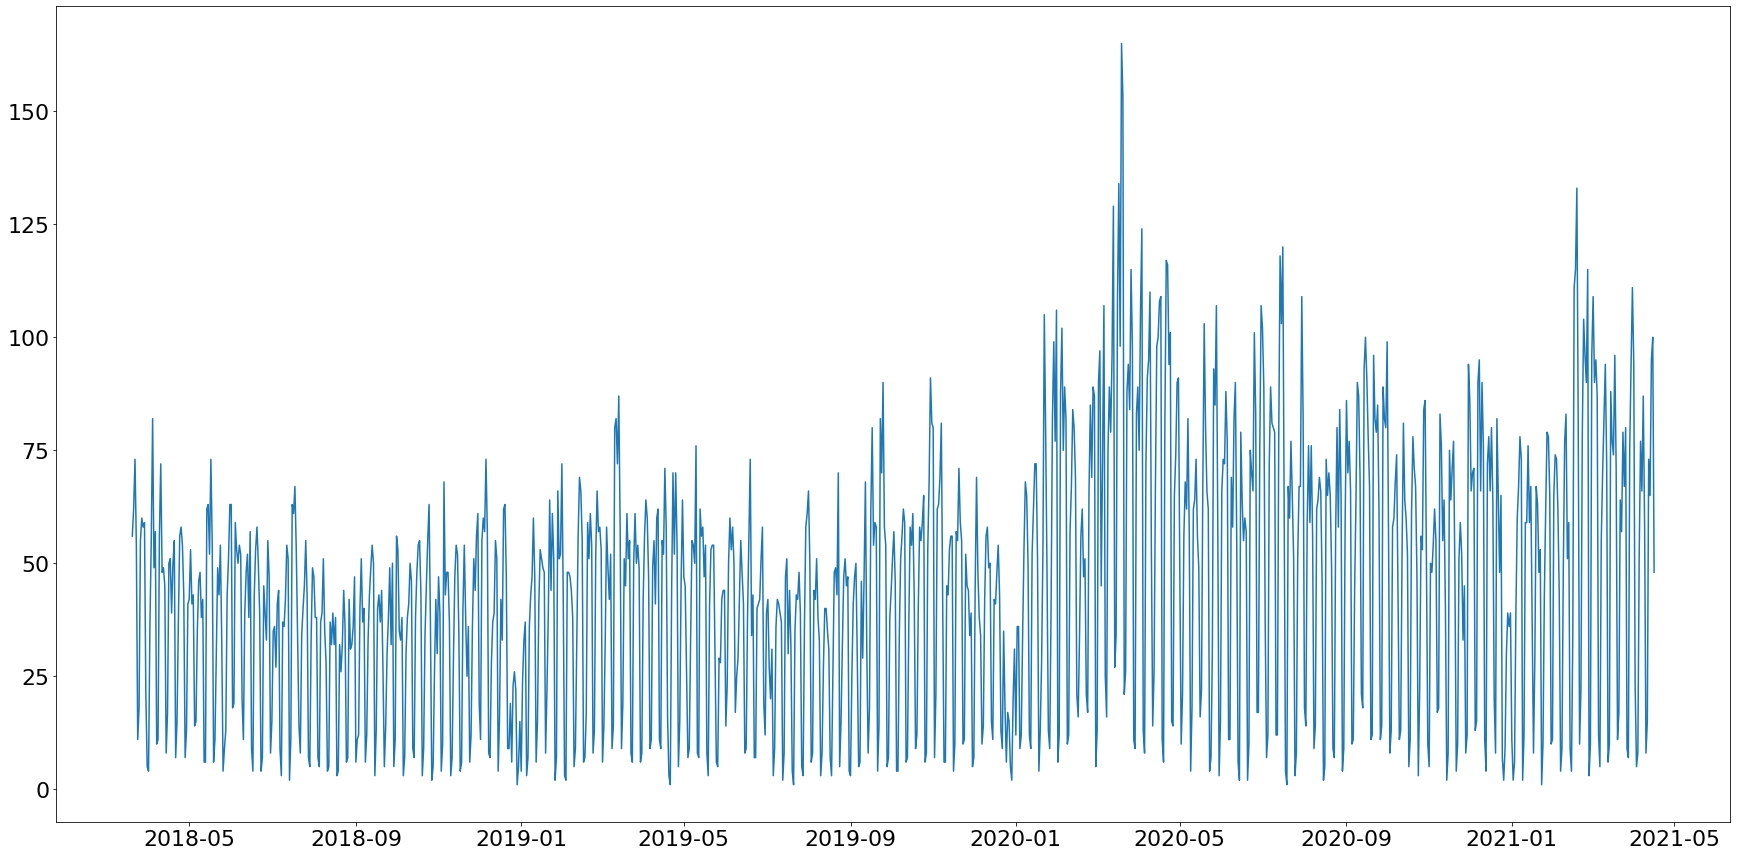

In [85]:
plt.figure(figsize=(30,15))
plt.rcParams.update({'font.size': 22})
plt.plot(days,counts)
# ax.xaxis.set_major_locator(MonthLocator())
plt.show()

In [57]:
# time_series.plot(kind='bar', figsize=(30,15))

In [64]:
time_series.max()

165

In [65]:
time_series.idxmax()

Timestamp('2020-03-19 00:00:00')

In [66]:
time_series.mean()

44.23597506678539

In [77]:
pre_2020 = time_series['2019-12-31':]
pre_2020

2019-12-31    31
2019-12-30    20
2019-12-29     2
2019-12-28     5
2019-12-27    15
              ..
2018-03-24    11
2018-03-23    54
2018-03-22    73
2018-03-21    62
2018-03-20    56
Length: 652, dtype: int64

In [75]:
pre_2020.mean()

36.07055214723926

In [83]:
# Odd way round because I have the newest first
y2020 = time_series['2020-12-31':'2020-01-01']
y2020

2020-12-31    39
2020-12-30    36
2020-12-29    39
2020-12-28    30
2020-12-27     9
              ..
2020-01-05    12
2020-01-04     9
2020-01-03    36
2020-01-02    36
2020-01-01    12
Length: 366, dtype: int64

In [84]:
y2020.mean()

55.63934426229508

In [86]:
y2021 = time_series[:'2020-01-01']
y2021

2021-04-16     48
2021-04-15    100
2021-04-14     95
2021-04-13     65
2021-04-12     73
             ... 
2020-01-05     12
2020-01-04      9
2020-01-03     36
2020-01-02     36
2020-01-01     12
Length: 471, dtype: int64

In [87]:
y2021.mean()

55.539278131634816

In [89]:
time_series

2021-04-16     48
2021-04-15    100
2021-04-14     95
2021-04-13     65
2021-04-12     73
             ... 
2018-03-24     11
2018-03-23     54
2018-03-22     73
2018-03-21     62
2018-03-20     56
Length: 1123, dtype: int64

In [108]:
rolling_time_series = time_series.sort_index(ascending=True).rolling(30).mean()
rolling_time_series.sort_index(ascending=False)

2021-04-16    57.066667
2021-04-15    57.933333
2021-04-14    57.166667
2021-04-13    56.933333
2021-04-12    55.100000
                ...    
2018-03-24          NaN
2018-03-23          NaN
2018-03-22          NaN
2018-03-21          NaN
2018-03-20          NaN
Length: 1123, dtype: float64

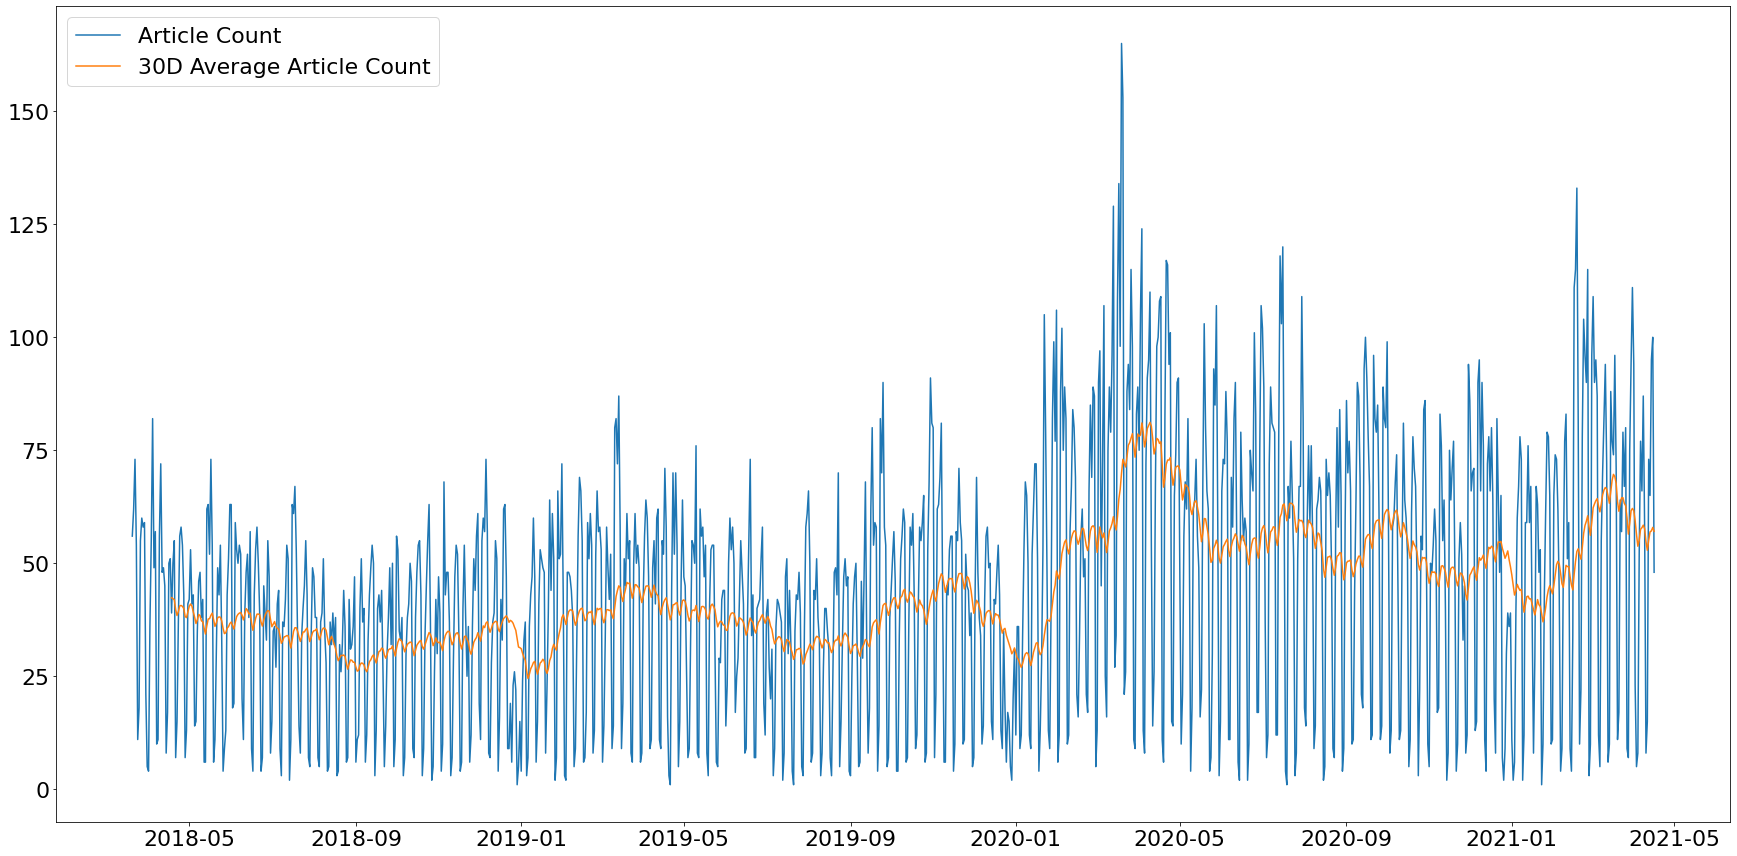

In [111]:
plt.figure(figsize=(30,15))
plt.rcParams.update({'font.size': 22})
plt.plot(time_series, label='Article Count')
plt.plot(rolling_time_series, label='30D Average Article Count')
plt.legend(loc="upper left")
plt.show()